# Day 1B — Machine Learning with PyTorch, Step by Step

This standalone notebook explains tensors, automatic differentiation, mini-batches, the training
loop, dropout, weight decay, early stopping, manual hyperparameter search, and classification.
PyTorch automates gradients—not experimental design.

In [1]:
import copy, itertools, random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
# Seed every random-number generator used in this notebook.
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
# Prefer a GPU when available; otherwise use the CPU.
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__,device)

2.13.0+cu130 cuda


## 1. Data boundaries and tensors

We recreate fictional data so the notebook is independent. Feature and target scaling are learned
from training only; the target is standardized for easier optimization and converted back for final
metrics. A tensor with `requires_grad=True` records operations; `.backward()` applies the chain rule.
Gradients accumulate, so training clears them every batch.

In [2]:
# Generate fictional inputs and a nonlinear regression target.
rng=np.random.default_rng(SEED); n=900
X=np.column_stack([rng.uniform(15,45,n),rng.uniform(20,85,n),rng.normal(size=n),rng.normal(size=n),rng.uniform(0,1,n)]).astype("float32")
y=(8+.45*X[:,0]-.08*X[:,1]+4*X[:,2]+2.5*X[:,3]**2-5*X[:,4]+2*np.sin(X[:,2])+rng.normal(0,1.8,n)).astype("float32")
# Split before calculating scaling statistics.
order=rng.permutation(n); nt,nv=int(.6*n),int(.2*n); it,iv,ix=order[:nt],order[nt:nt+nv],order[nt+nv:]
X_train,y_train=X[it],y[it]; X_val,y_val=X[iv],y[iv]; X_test,y_test=X[ix],y[ix]
# Store training-only feature and target scaling.
x_mean,x_std=X_train.mean(0),X_train.std(0); y_mean,y_std=y_train.mean(),y_train.std()
X_train=(X_train-x_mean)/x_std; X_val=(X_val-x_mean)/x_std; X_test=(X_test-x_mean)/x_std
y_train_s=(y_train-y_mean)/y_std; y_val_s=(y_val-y_mean)/y_std
x=torch.tensor([2.],requires_grad=True); demo=(3*x-7)**2; demo.backward(); print("demo loss/gradient:",demo.item(),x.grad.item())

demo loss/gradient: 1.0 -6.0


## 2. Dataset, mini-batches, and network

`TensorDataset` aligns features and targets; `DataLoader` batches and shuffles training rows. The MLP
uses ReLU nonlinearities and dropout. `model.train()` enables dropout; `model.eval()` disables it.

In [3]:
def loader(X,y,batch,shuffle):
    # TensorDataset keeps corresponding feature and target rows aligned.
    dataset=TensorDataset(torch.tensor(X),torch.tensor(y[:,None]))
    return DataLoader(dataset,batch_size=batch,shuffle=shuffle)

class MLP(nn.Module):
    def __init__(self,width=32,dropout=.1):
        super().__init__()
        # Dropout is configured directly in the model architecture.
        self.net=nn.Sequential(
            nn.Linear(5,width), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(width,width), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(width,1),
        )
    def forward(self,x): return self.net(x)
model=MLP().to(device); print(model); print("parameters:",sum(p.numel() for p in model.parameters()))

MLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
parameters: 1281


## 3. Training and regularization

Each batch performs **clear gradients → predict → loss → backpropagate → update**. The beginner loop
keeps a plain MSE loss. Regularization is configured in the standard simple places:

- `nn.Dropout(...)` is directly part of the model and regularizes hidden activations;
- AdamW `weight_decay=...` applies L2-style weight shrinkage during updates;
- early stopping restores the checkpoint with the best validation loss.

No manual regularization term is mixed into the loss in this introductory version.

In [4]:
def evaluate(model,data):
    # eval() disables dropout; no_grad() avoids building gradient graphs.
    model.eval(); total=count=0
    with torch.no_grad():
        for xb,yb in data:
            xb,yb=xb.to(device),yb.to(device); total+=torch.sum((model(xb)-yb)**2).item(); count+=len(xb)
    return total/count

def train(config,epochs=140,patience=15):
    # Create a fresh model and optimizer for each hyperparameter candidate.
    torch.manual_seed(SEED); model=MLP(config["width"],config["dropout"]).to(device)
    opt=torch.optim.AdamW(model.parameters(),lr=config["lr"],weight_decay=config["decay"])
    tr=loader(X_train,y_train_s,config["batch"],True); va=loader(X_val,y_val_s,256,False)
    best=float("inf"); state=None; stale=0; history={"train":[],"val":[]}
    for epoch in range(epochs):
        model.train(); total=count=0
        for xb,yb in tr:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad()                         # 1. clear gradients from the last batch
            prediction=model(xb)                  # 2. forward pass
            loss=nn.functional.mse_loss(prediction,yb)  # 3. plain data-fitting loss
            loss.backward()                       # 4. compute gradients with autograd
            opt.step()                            # 5. update weights, including weight decay
            total+=loss.item()*len(xb); count+=len(xb)
        value=evaluate(model,va); history["train"].append(total/count); history["val"].append(value)
        if value<best-1e-6: best=value; state=copy.deepcopy(model.state_dict()); best_epoch=epoch+1; stale=0
        else: stale+=1
        if stale>=patience: break
    model.load_state_dict(state); return model,history,best,best_epoch

## 4. One run and its learning curves

A widening train/validation gap suggests overfitting; both curves staying high may indicate
underfitting, weak features, or optimization trouble. Curves are diagnostic evidence, not an
automatic decision rule.

best epoch / standardized validation RMSE: 77 0.2352144706472737


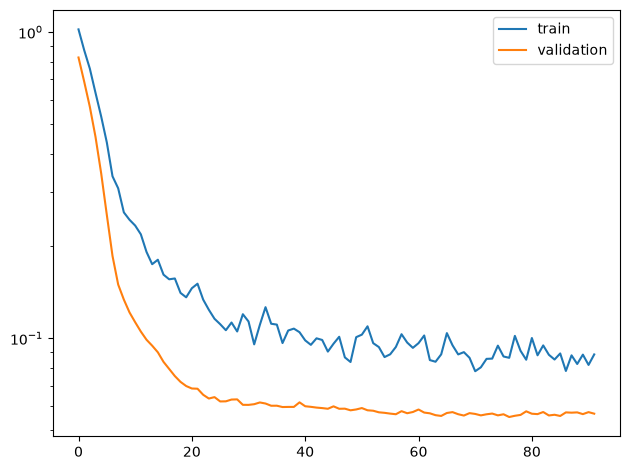

In [5]:
config={"width":32,"dropout":.1,"lr":1e-3,"decay":1e-4,"batch":64}
model,history,score,epoch=train(config)
print("best epoch / standardized validation RMSE:",epoch,score**.5)
plt.plot(history["train"],label="train"); plt.plot(history["val"],label="validation"); plt.yscale("log"); plt.legend(); plt.tight_layout()

## 5. Manual hyperparameter search—no tuning library

We create a Cartesian grid and reproducibly sample eight combinations to keep runtime short. Every
candidate receives the same split and is ranked only by validation loss. For expensive networks,
random search, successive halving, or Bayesian optimization can spend compute more selectively.

In [6]:
space=list(itertools.product([16,32],[0.,.2],[3e-4,1e-3],[0.,1e-3]))
results=[]
for width,dropout,lr,decay in random.Random(SEED).sample(space,8):
    cfg={"width":width,"dropout":dropout,"lr":lr,"decay":decay,"batch":64}
    candidate,_,score,epoch=train(cfg,epochs=110); results.append({**cfg,"val_RMSE":score**.5,"epoch":epoch,"state":copy.deepcopy(candidate.state_dict())})
    print(f"RMSE={score**.5:.3f}",cfg)
sorted([{k:v for k,v in r.items() if k!="state"} for r in results],key=lambda row:row["val_RMSE"])

RMSE=0.246 {'width': 16, 'dropout': 0.0, 'lr': 0.001, 'decay': 0.001, 'batch': 64}


RMSE=0.246 {'width': 16, 'dropout': 0.0, 'lr': 0.0003, 'decay': 0.0, 'batch': 64}


RMSE=0.238 {'width': 32, 'dropout': 0.0, 'lr': 0.001, 'decay': 0.001, 'batch': 64}


RMSE=0.278 {'width': 16, 'dropout': 0.2, 'lr': 0.0003, 'decay': 0.0, 'batch': 64}


RMSE=0.241 {'width': 32, 'dropout': 0.2, 'lr': 0.001, 'decay': 0.001, 'batch': 64}


RMSE=0.245 {'width': 32, 'dropout': 0.2, 'lr': 0.0003, 'decay': 0.001, 'batch': 64}


RMSE=0.246 {'width': 16, 'dropout': 0.0, 'lr': 0.001, 'decay': 0.0, 'batch': 64}


RMSE=0.246 {'width': 16, 'dropout': 0.0, 'lr': 0.0003, 'decay': 0.001, 'batch': 64}


[{'width': 32,
  'dropout': 0.0,
  'lr': 0.001,
  'decay': 0.001,
  'batch': 64,
  'val_RMSE': 0.23782978473485153,
  'epoch': 74},
 {'width': 32,
  'dropout': 0.2,
  'lr': 0.001,
  'decay': 0.001,
  'batch': 64,
  'val_RMSE': 0.24099549673682366,
  'epoch': 61},
 {'width': 32,
  'dropout': 0.2,
  'lr': 0.0003,
  'decay': 0.001,
  'batch': 64,
  'val_RMSE': 0.24512719500791624,
  'epoch': 108},
 {'width': 16,
  'dropout': 0.0,
  'lr': 0.001,
  'decay': 0.0,
  'batch': 64,
  'val_RMSE': 0.24598646836250723,
  'epoch': 33},
 {'width': 16,
  'dropout': 0.0,
  'lr': 0.001,
  'decay': 0.001,
  'batch': 64,
  'val_RMSE': 0.2460036124469889,
  'epoch': 33},
 {'width': 16,
  'dropout': 0.0,
  'lr': 0.0003,
  'decay': 0.001,
  'batch': 64,
  'val_RMSE': 0.24615858727559806,
  'epoch': 102},
 {'width': 16,
  'dropout': 0.0,
  'lr': 0.0003,
  'decay': 0.0,
  'batch': 64,
  'val_RMSE': 0.24616756240519908,
  'epoch': 102},
 {'width': 16,
  'dropout': 0.2,
  'lr': 0.0003,
  'decay': 0.0,
  'batch':

## 6. Frozen test evaluation and deployment information

Load the best validation checkpoint before opening test data. Convert predictions to original units.
Save feature order, scaling arrays, architecture, package versions, and thresholds with the state
dictionary; weights alone are not a complete inference pipeline.

In [7]:
best=min(results,key=lambda r:r["val_RMSE"]); final=MLP(best["width"],best["dropout"]).to(device); final.load_state_dict(best["state"]); final.eval()
with torch.no_grad(): prediction=final(torch.tensor(X_test).to(device)).cpu().numpy().ravel()*y_std+y_mean
error=y_test-prediction
print("test:",{"MAE":np.mean(abs(error)),"RMSE":np.sqrt(np.mean(error**2)),"R2":1-np.sum(error**2)/np.sum((y_test-y_test.mean())**2)})

test: {'MAE': np.float32(1.6272013), 'RMSE': np.float32(2.081982), 'R2': np.float32(0.9282237)}


## 7. Classification changes the output and loss

Binary classification uses one output **logit** and `BCEWithLogitsLoss`. Do not put sigmoid inside
the model during training; the combined loss is numerically stable. Apply `torch.sigmoid` for
probabilities. Multiclass problems use one logit per class and `CrossEntropyLoss`.

In [8]:
threshold=np.median(y_train); features=torch.tensor(X_train).to(device); labels=torch.tensor((y_train>threshold).astype("float32")[:,None]).to(device)
classifier=nn.Sequential(nn.Linear(5,16),nn.ReLU(),nn.Linear(16,1)).to(device); opt=torch.optim.AdamW(classifier.parameters(),lr=1e-3,weight_decay=1e-4)
for _ in range(100):
    opt.zero_grad(); loss=nn.functional.binary_cross_entropy_with_logits(classifier(features),labels); loss.backward(); opt.step()
classifier.eval()
with torch.no_grad(): predicted=torch.sigmoid(classifier(torch.tensor(X_val).to(device))).cpu().numpy().ravel()>=.5
print("validation accuracy:",np.mean(predicted==(y_val>threshold)))

validation accuracy: 0.7777777777777778


## 8. Common mistakes and exercises

Forgetting `zero_grad()` accumulates gradients; forgetting `eval()` leaves dropout active; omitting
`no_grad()` wastes evaluation memory; scaling before splitting leaks information; tuning from test
results invalidates the final estimate; combining excessive weight decay and dropout can underfit.

Exercises: add a second output, compare each regularizer separately, implement k-fold validation,
save/reload the full artifact, or replace the MLP with a 1D CNN for ordered signals.